Dec0922: This is a continuous, 33-minute file featuring identical stims. at minutes 5, 12, 19, and 27 (the last stim. was administered a minute later than planned due to an issue at the imaging rig); the corresponding time steps would be 122175, 293220, 464265, and 659745. The protocol used in this experiment is very similar to the one employed in the Nov2122 file, which, I believe, is the one from which you've been generating your existing analysis, Vince. Despite this similarity, the response of the recorded population to repeated stimulation is different here than in the Nov2122 file, which might make it worthwhile for you to analyze. 

In [1]:
## Import peaks from npy file
import numpy as np
peak_times = np.load('../data/sea_slug/Dec0922_peak_times2.npy', allow_pickle=True).item()  # Load as dictionary

In [2]:
sr = 407.25
stimuli = [time / (sr * 60) for time in [122175, 293220, 464265, 659745]]

In [3]:
stimuli

[5.0, 12.0, 19.0, 27.0]

In [4]:
T = 33

In [5]:
import matplotlib.pyplot as plt
## Compile with tikz and times font
plt.rc('text', usetex=True)
plt.rc('font', family='times')

In [6]:
import hep

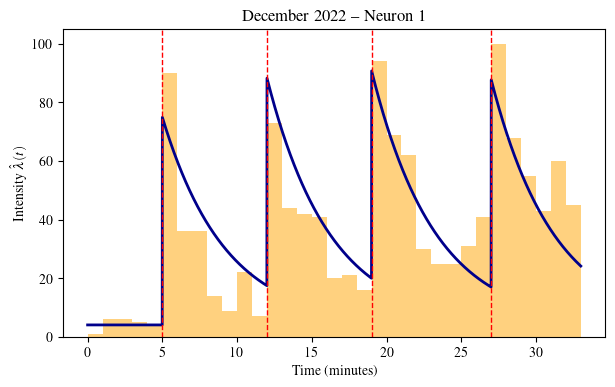

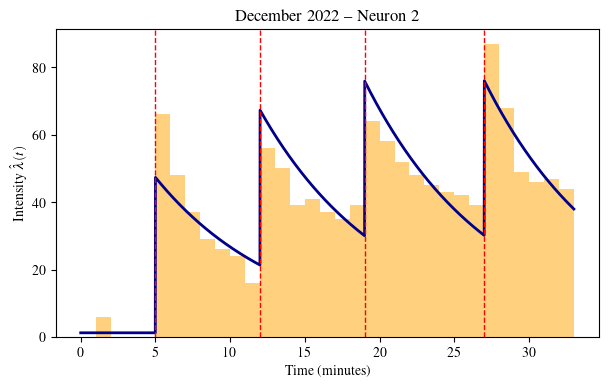

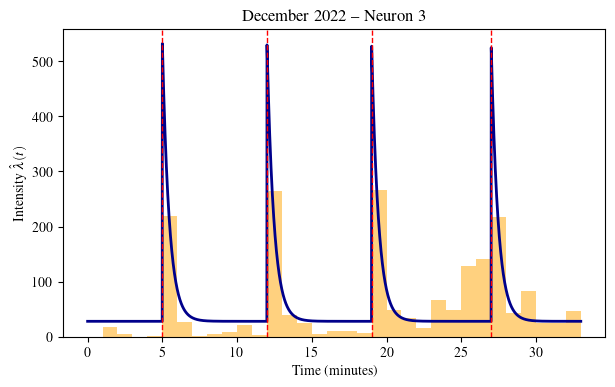

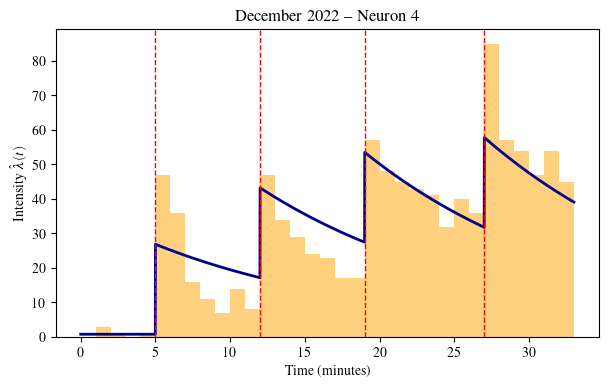

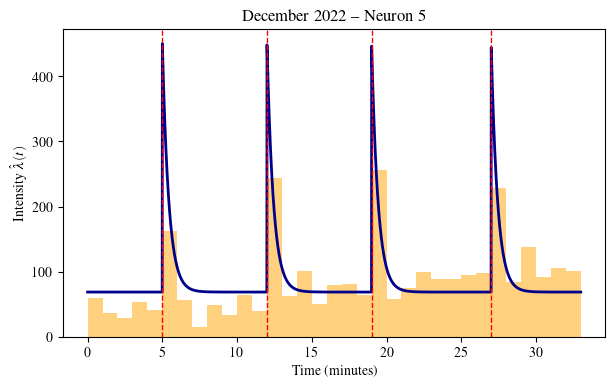

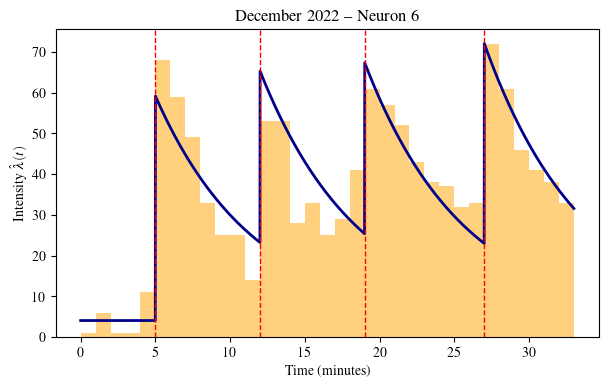

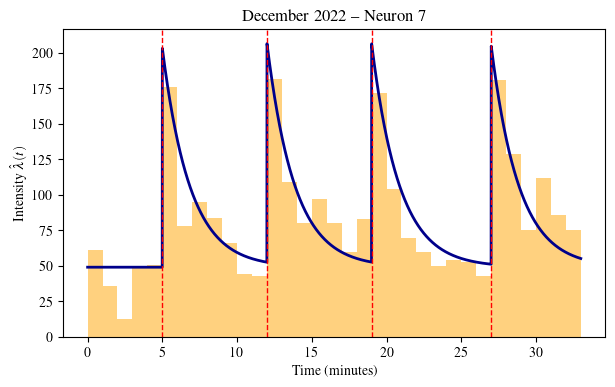

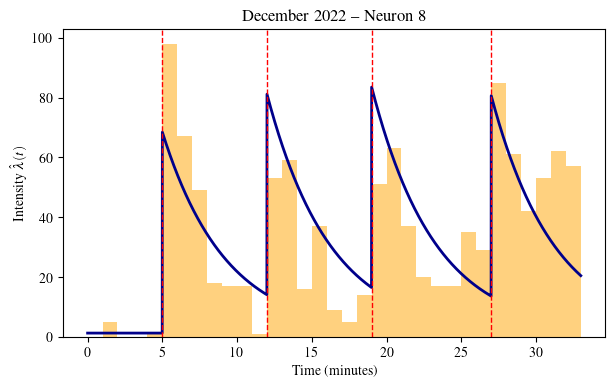

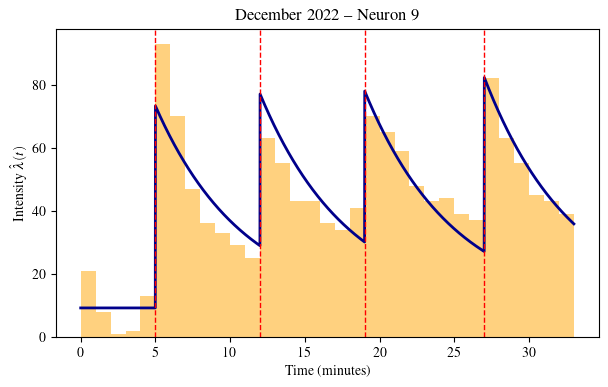

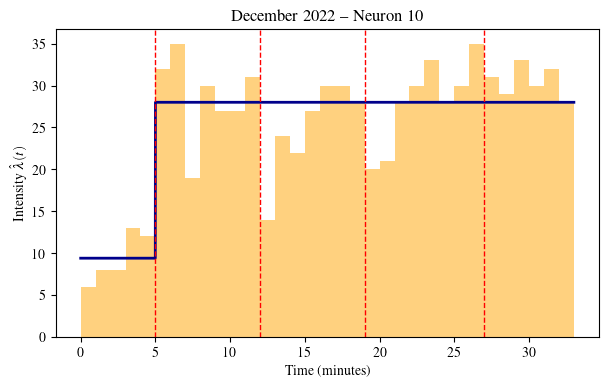

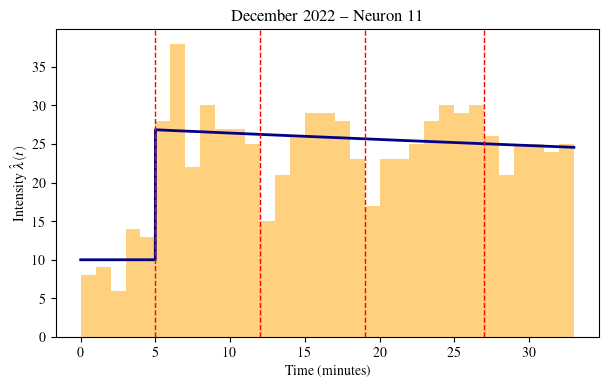

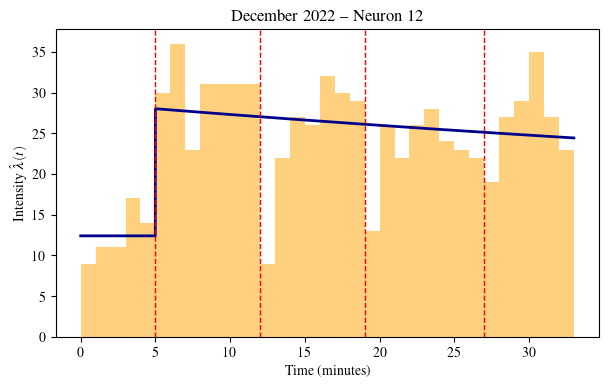

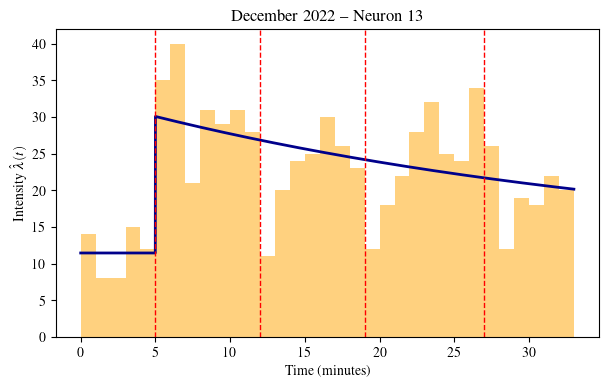

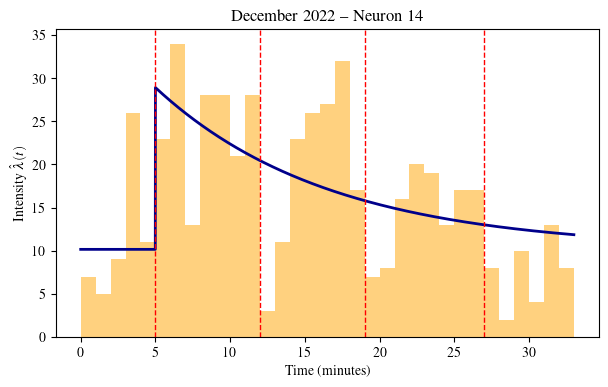

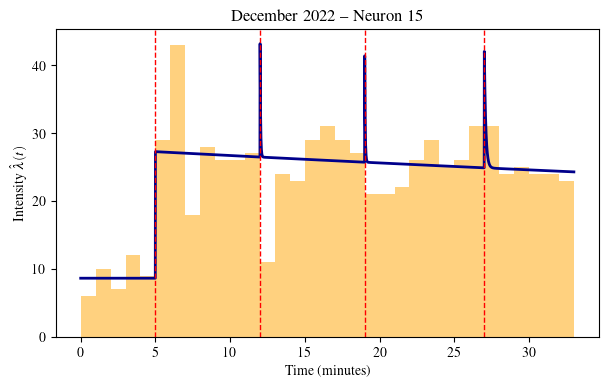

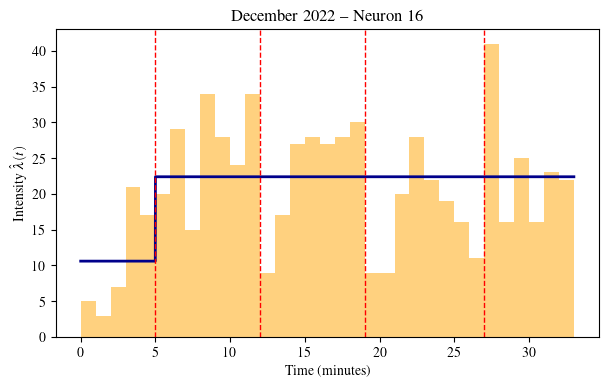

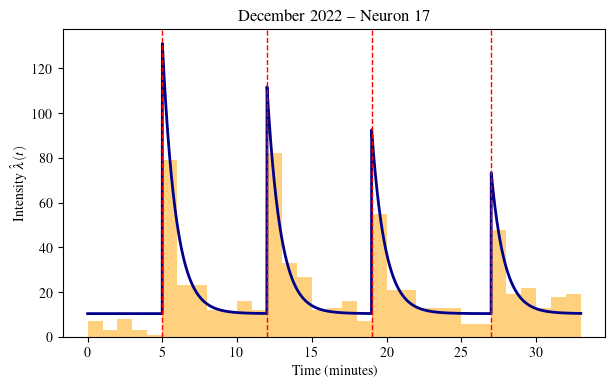

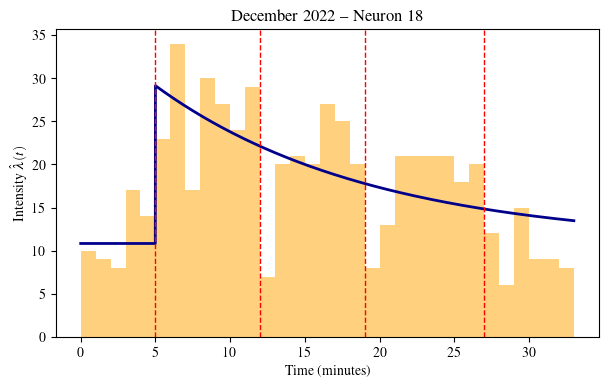

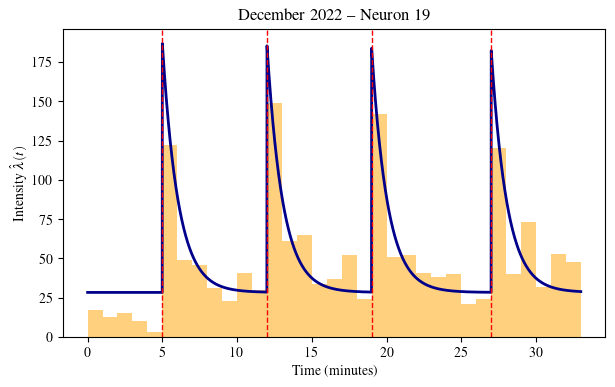

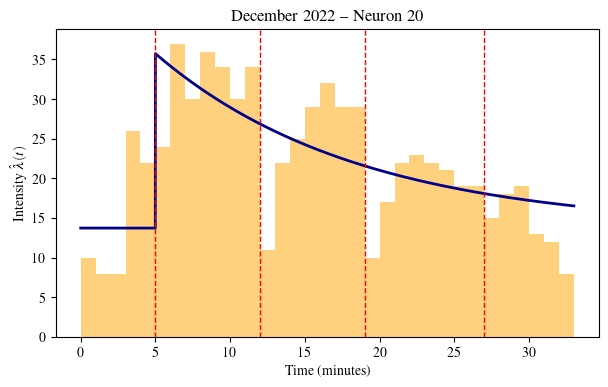

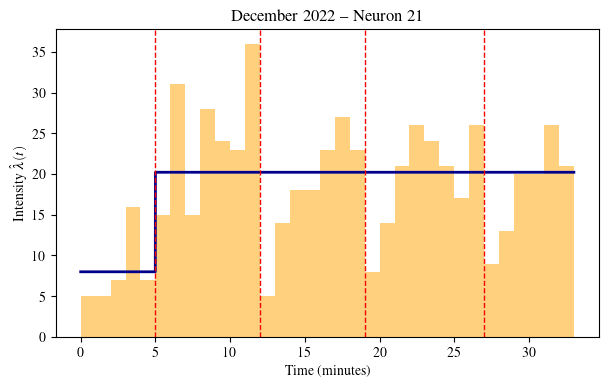

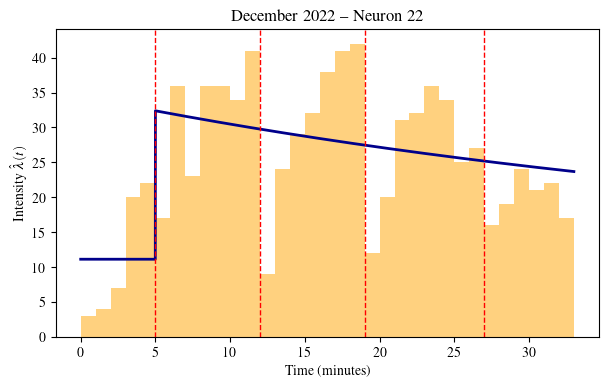

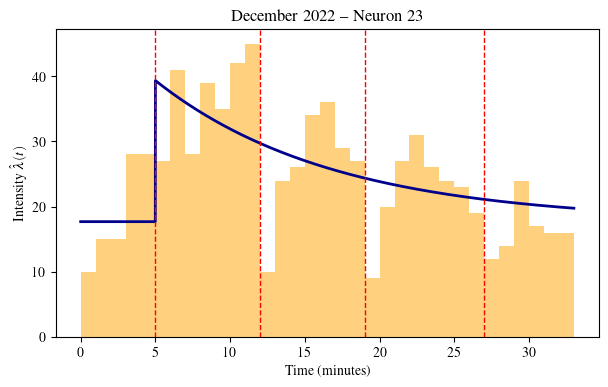

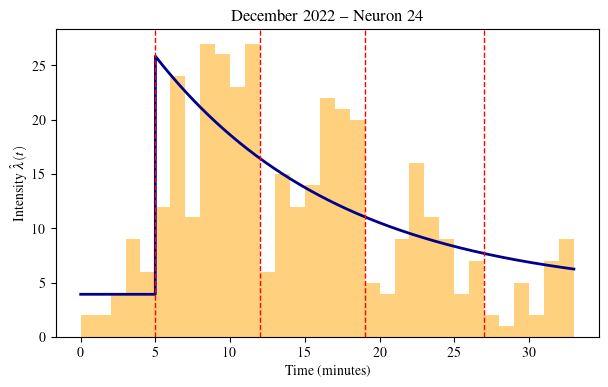

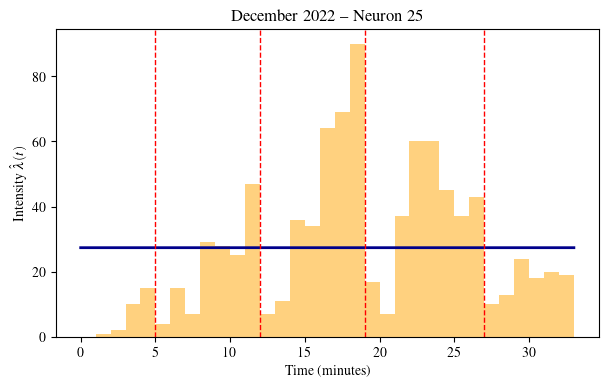

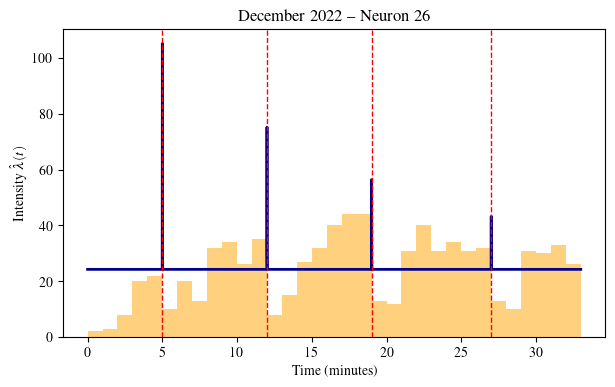

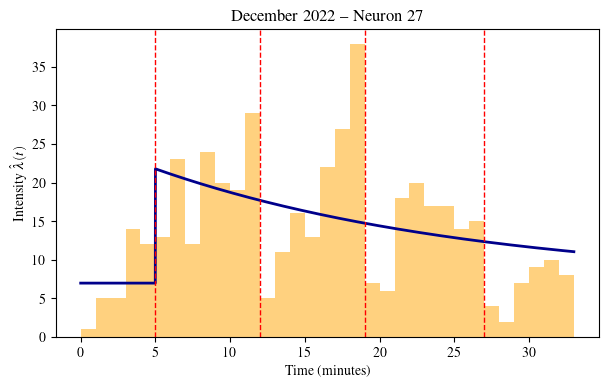

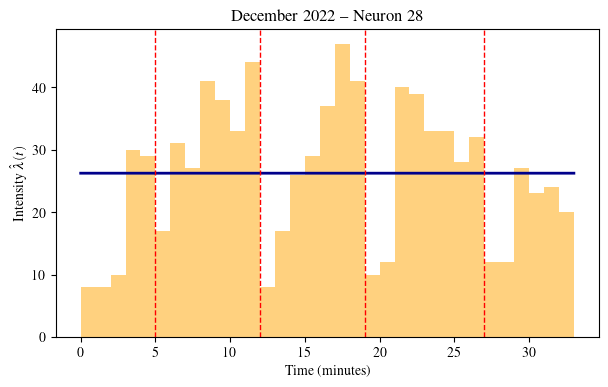

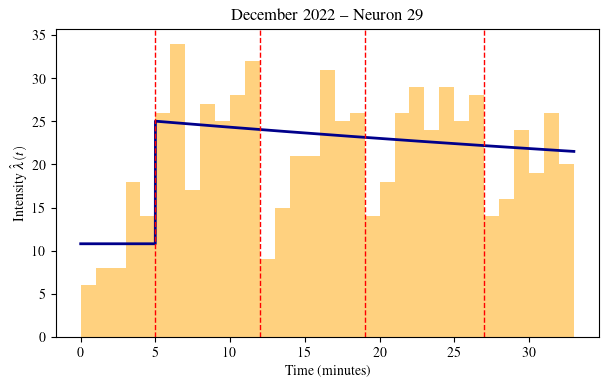

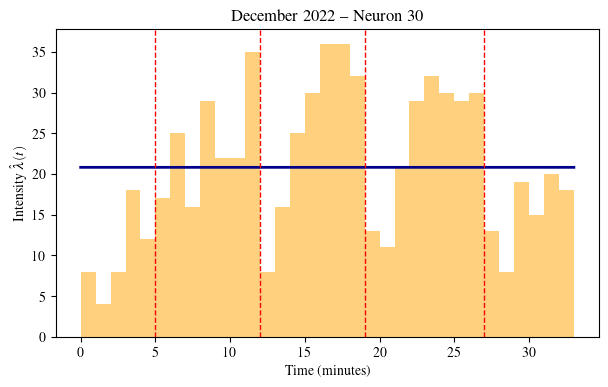

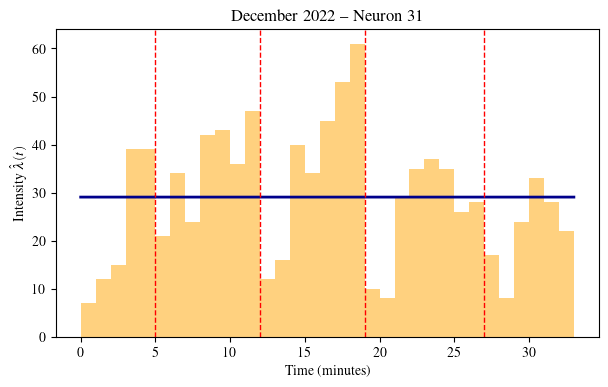

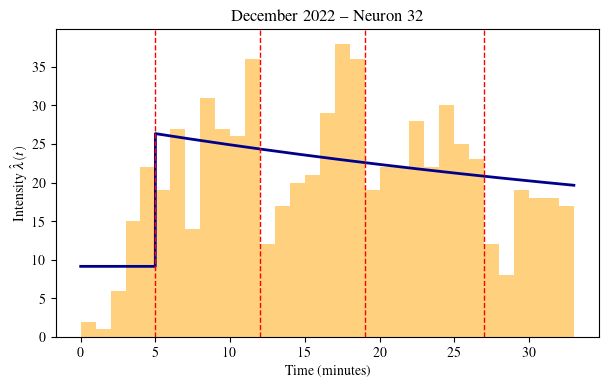

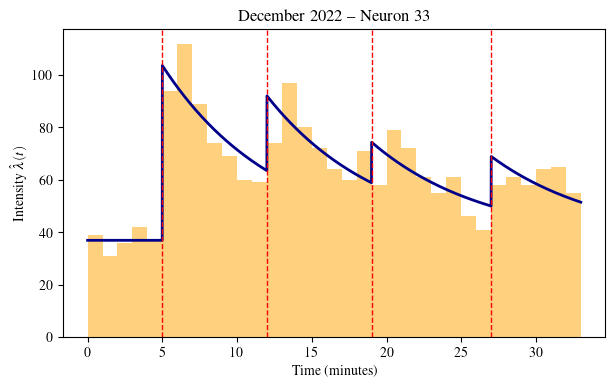

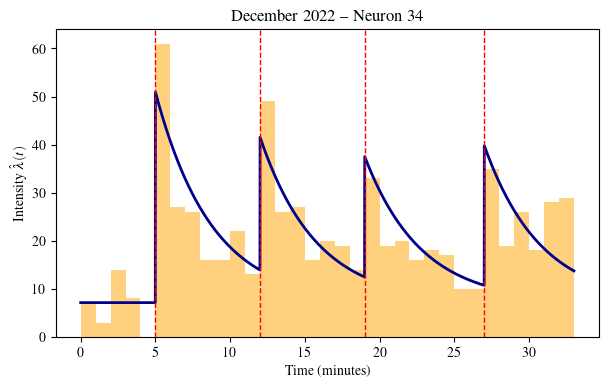

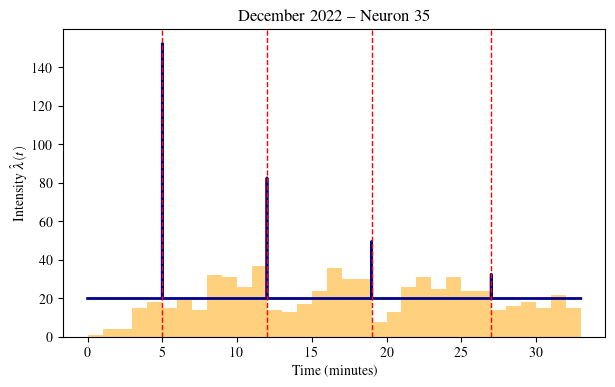

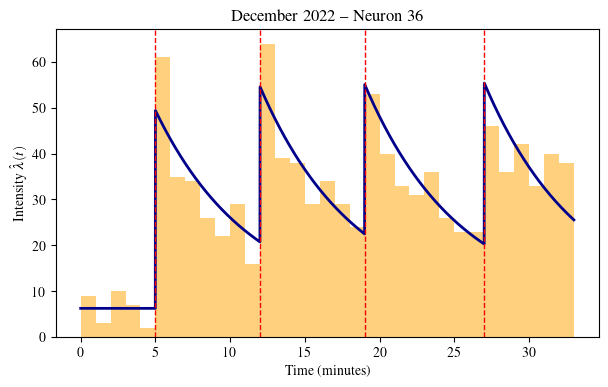

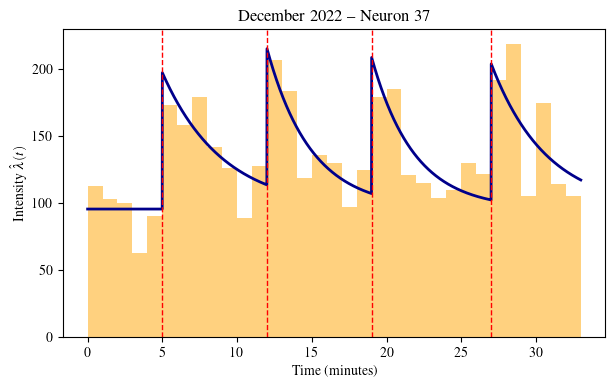

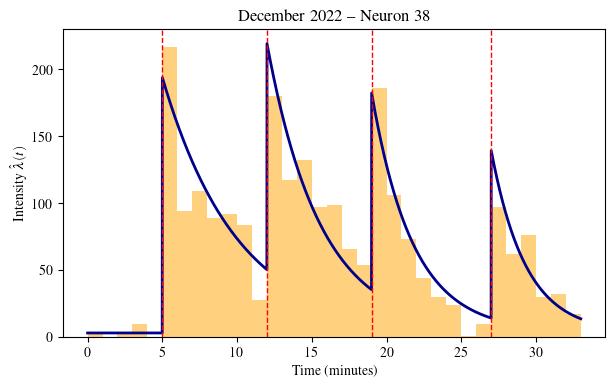

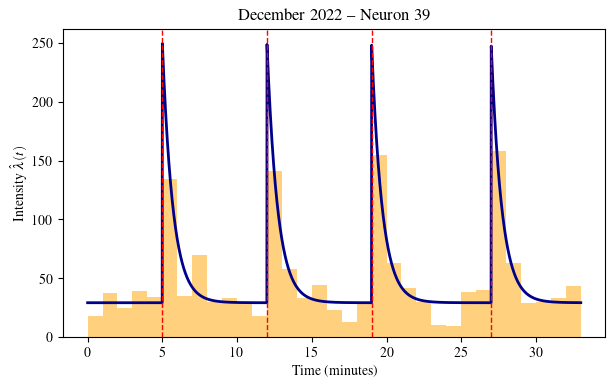

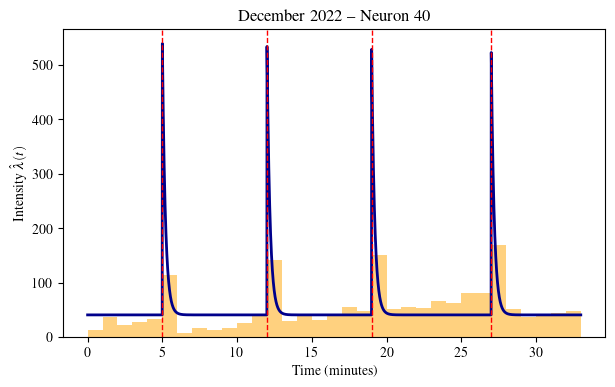

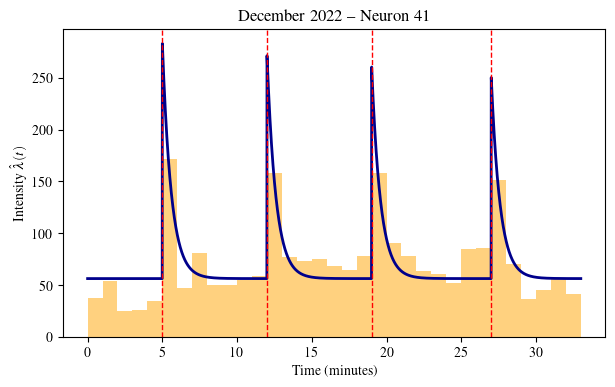

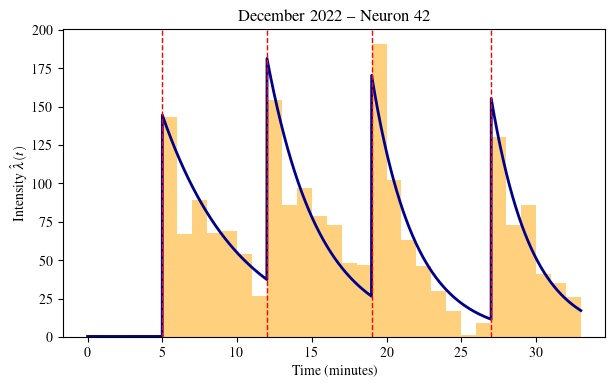

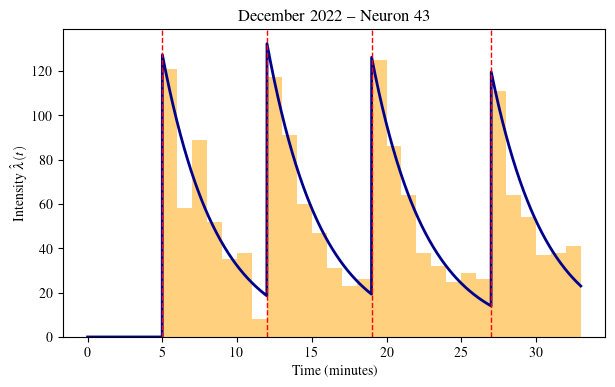

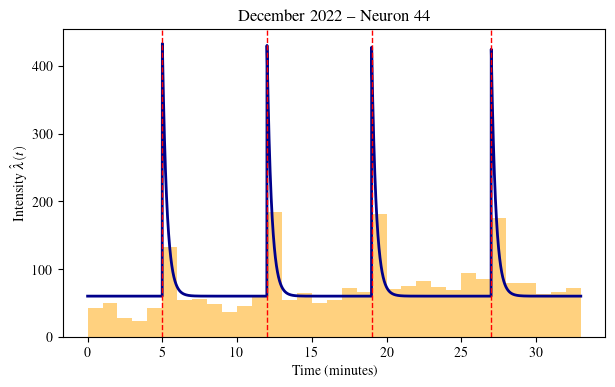

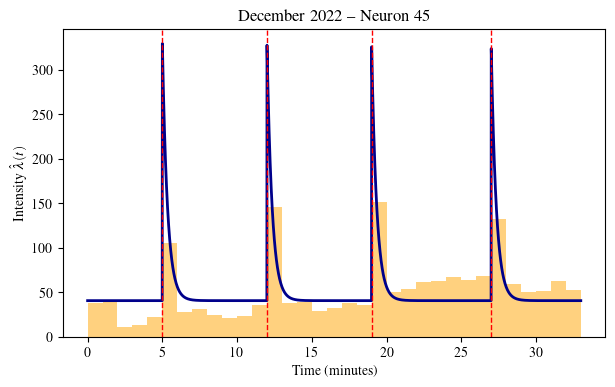

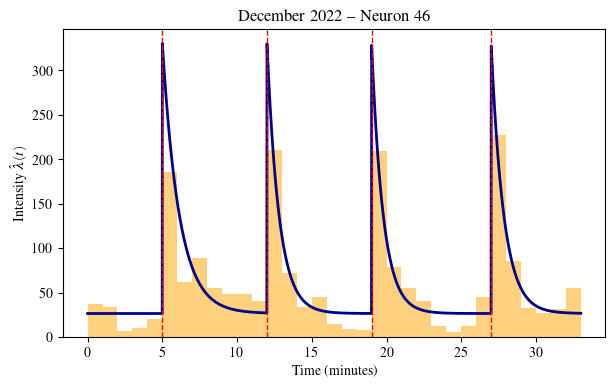

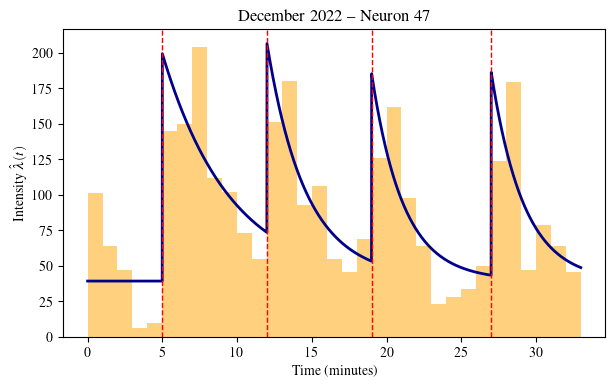

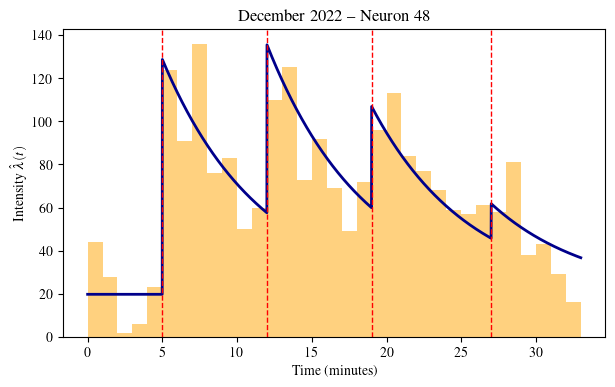

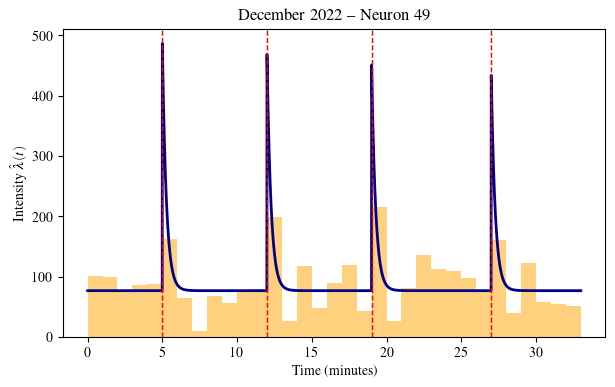

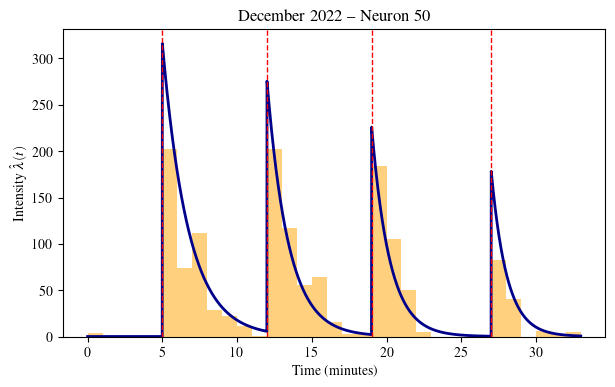

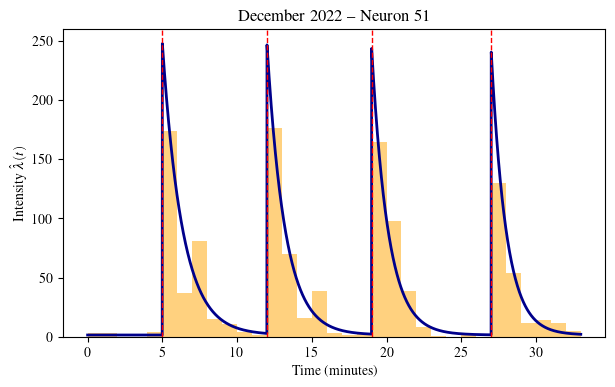

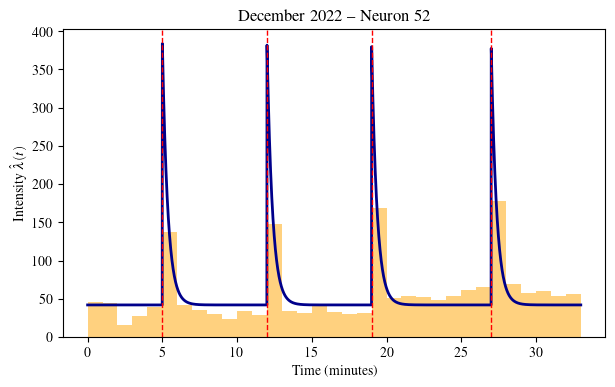

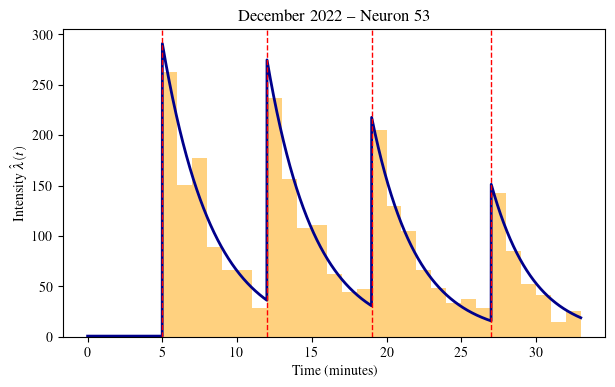

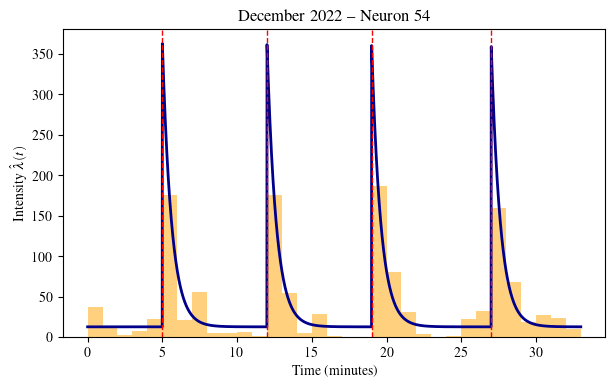

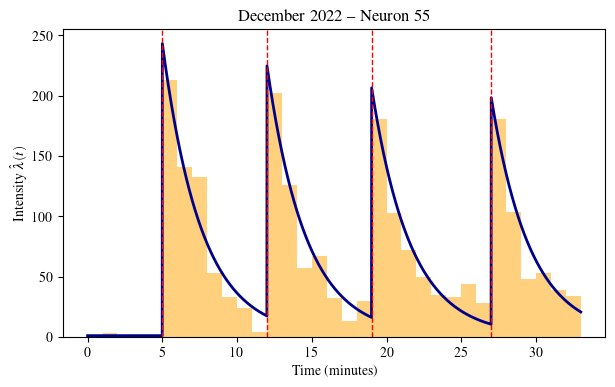

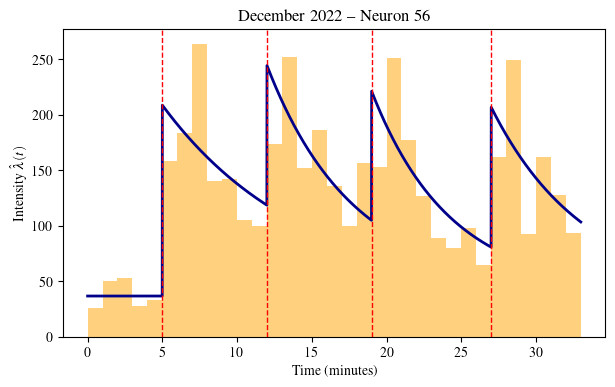

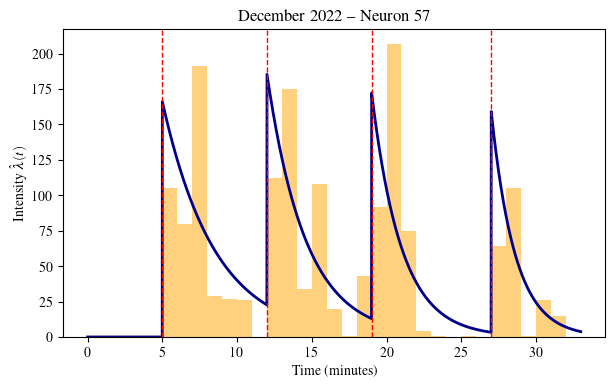

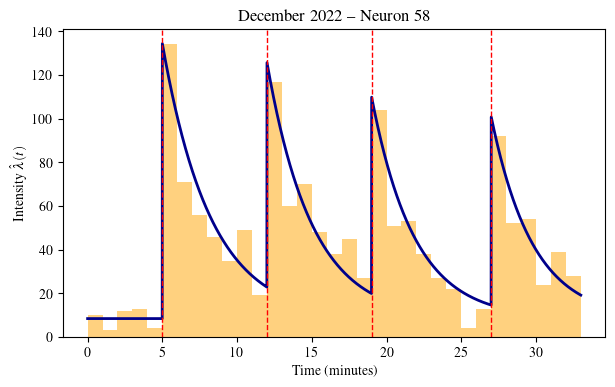

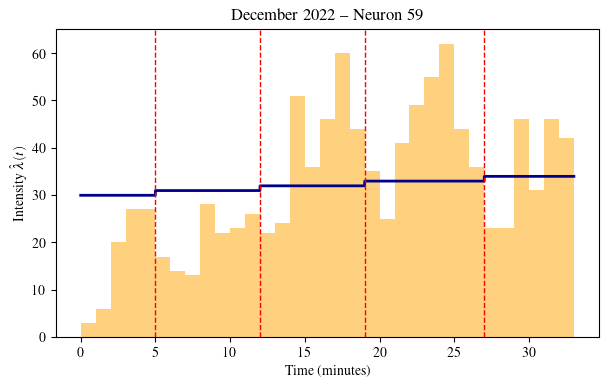

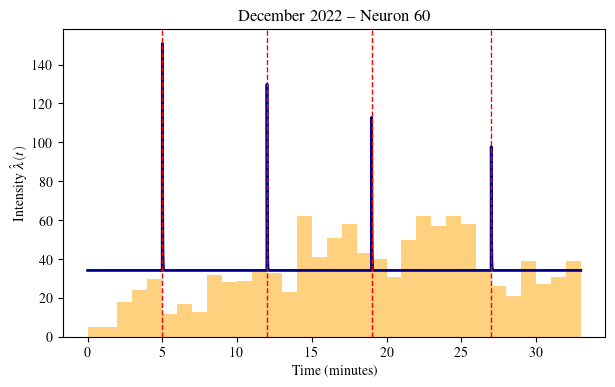

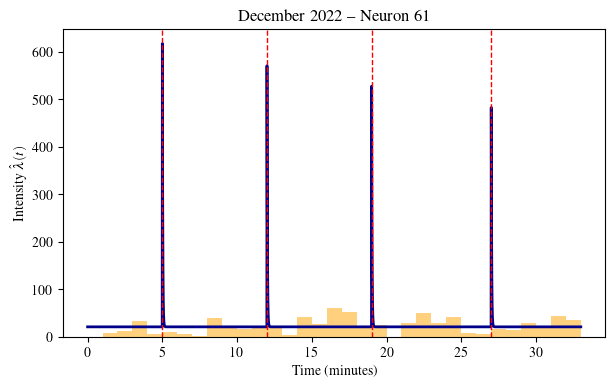

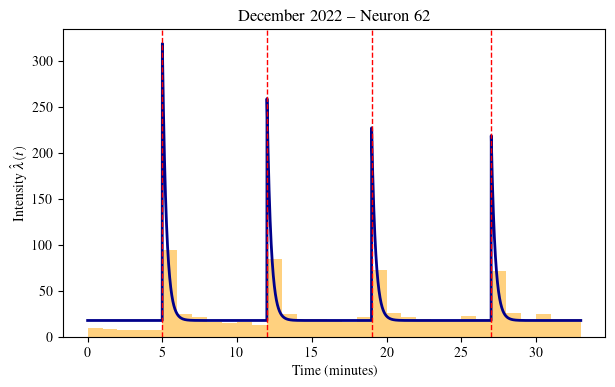

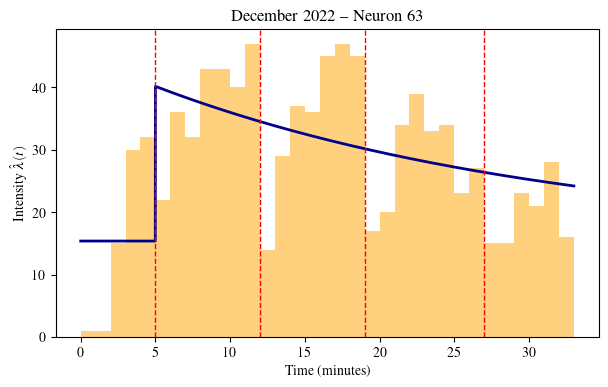

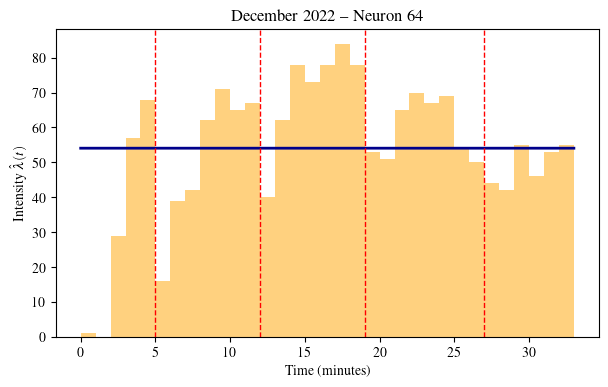

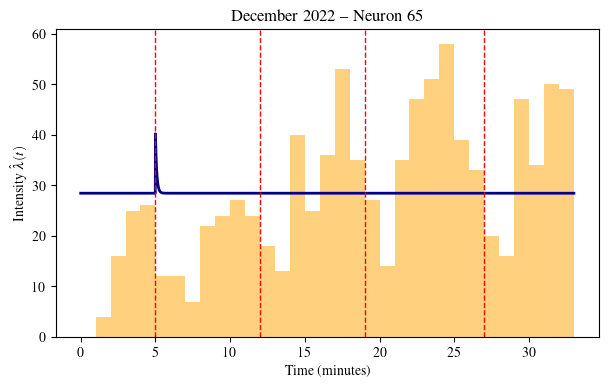

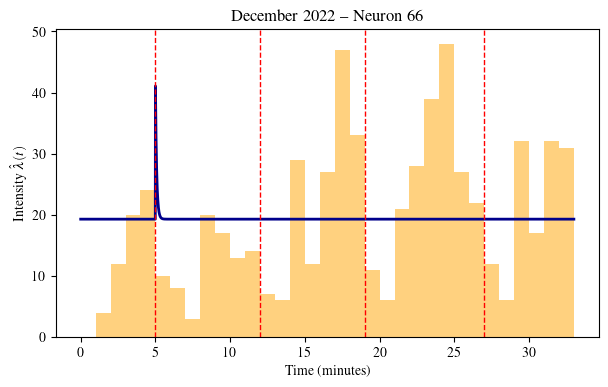

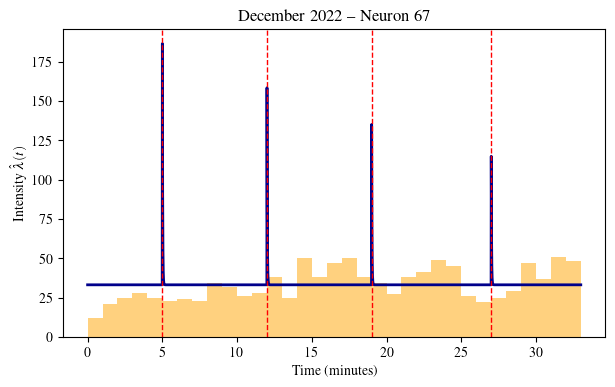

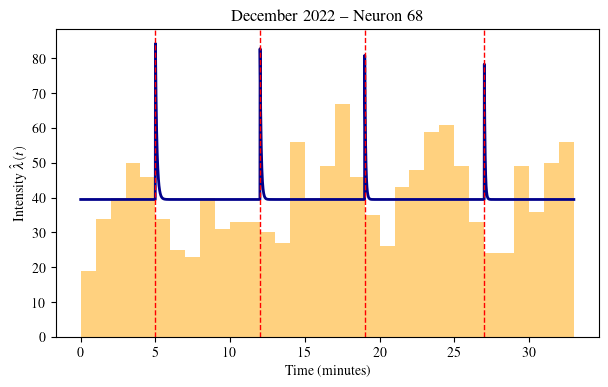

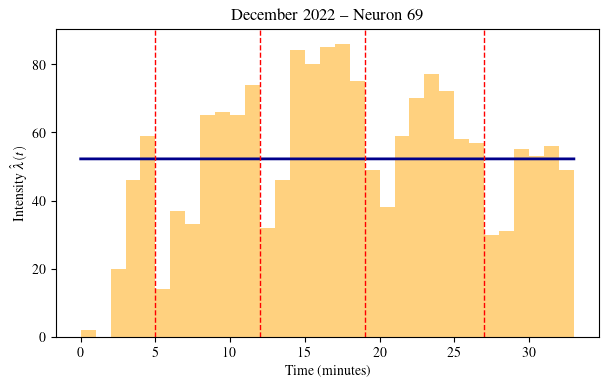

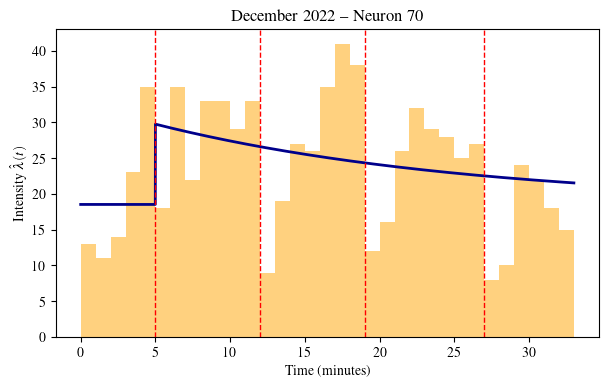

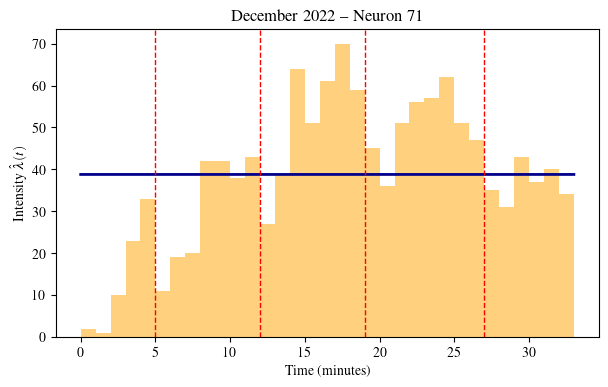

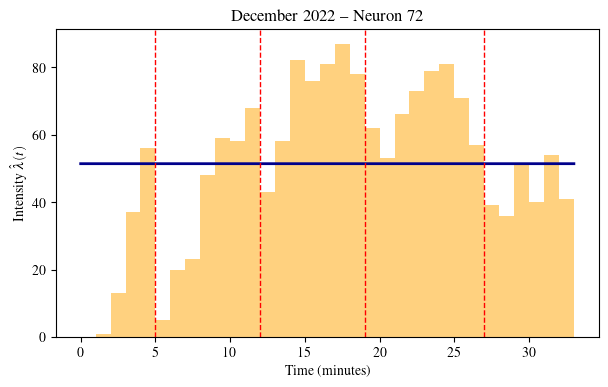

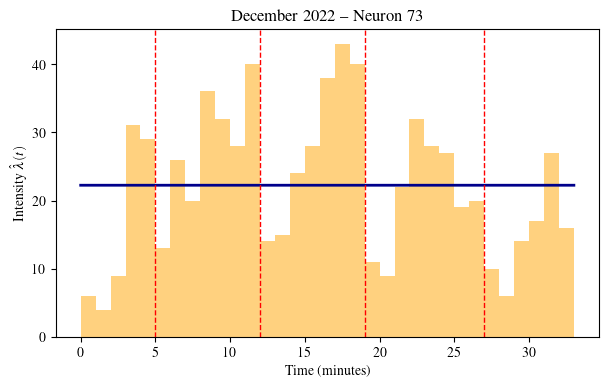

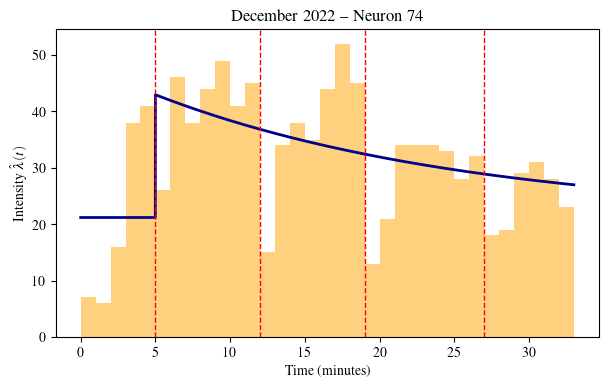

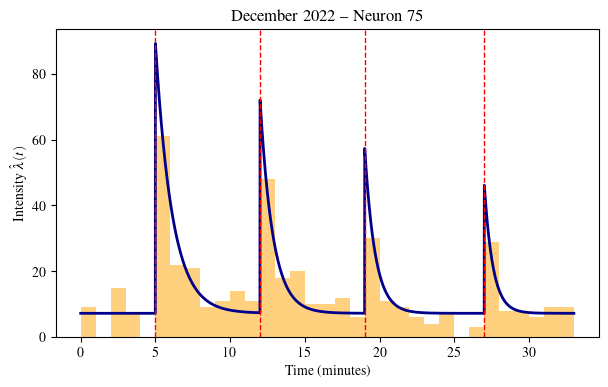

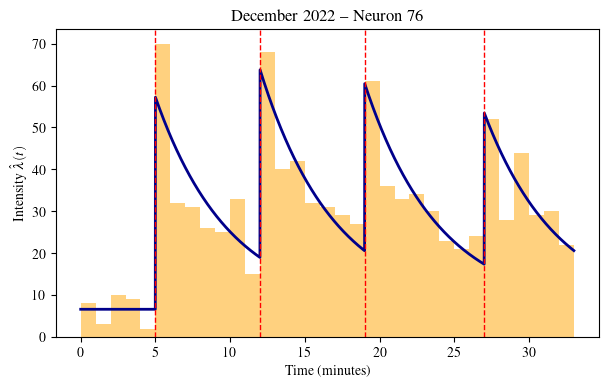

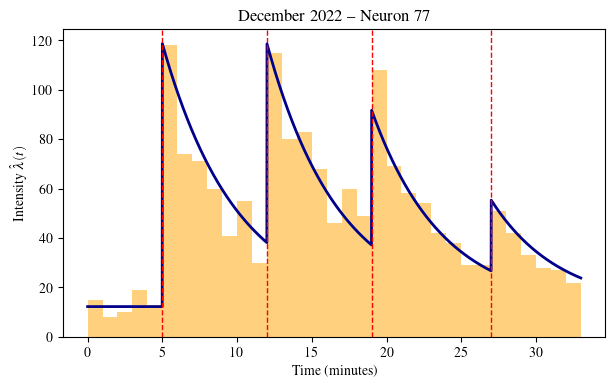

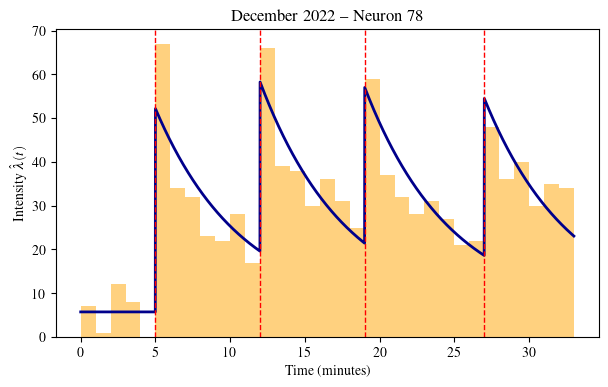

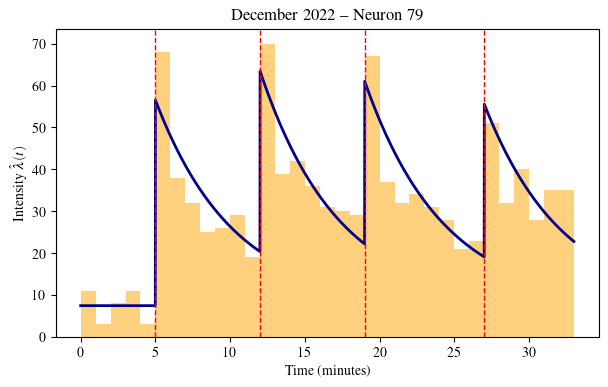

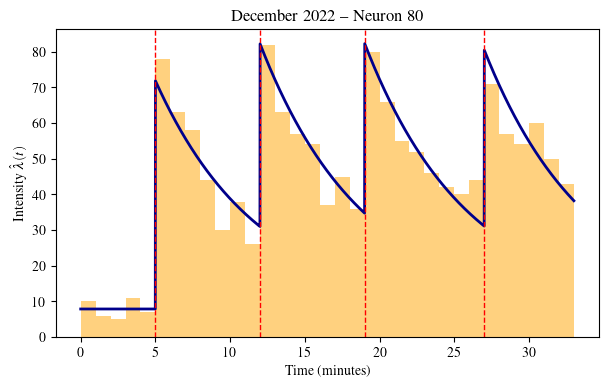

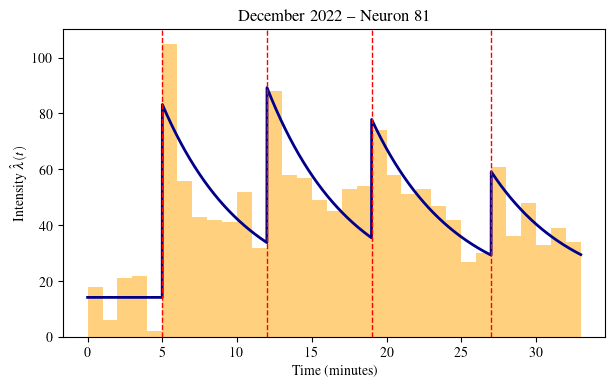

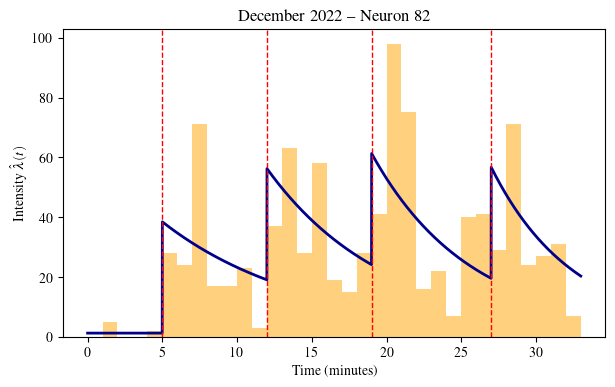

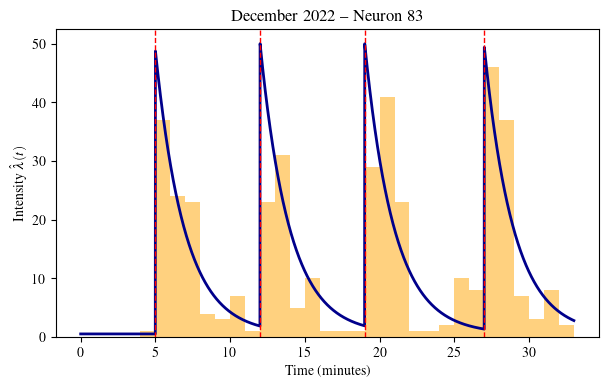

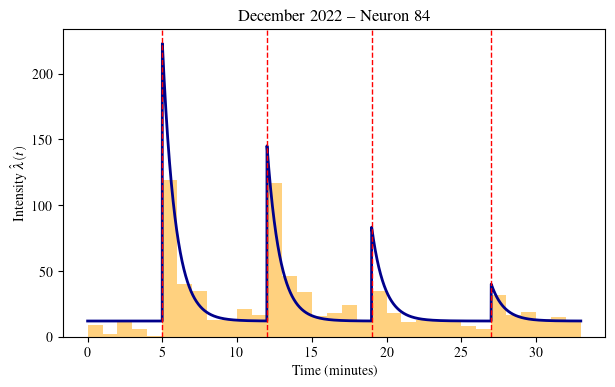

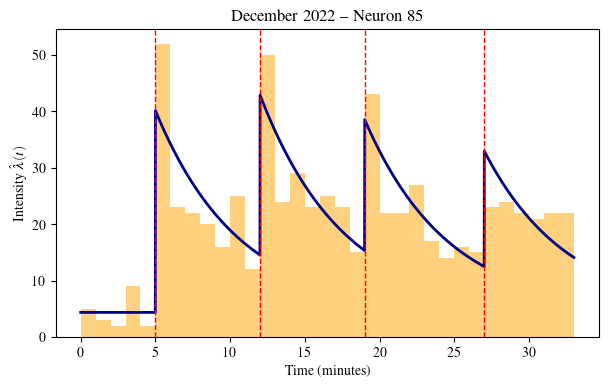

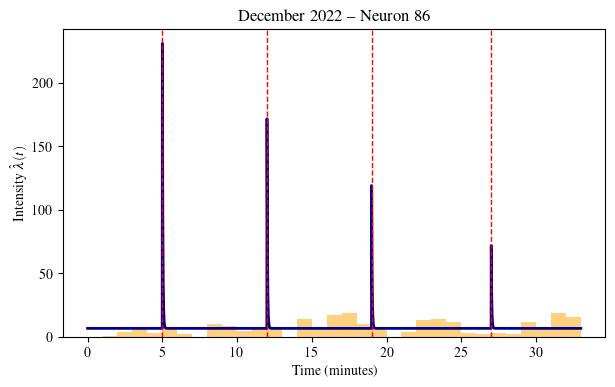

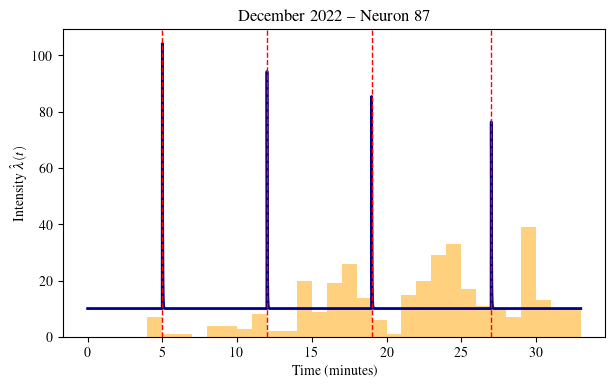

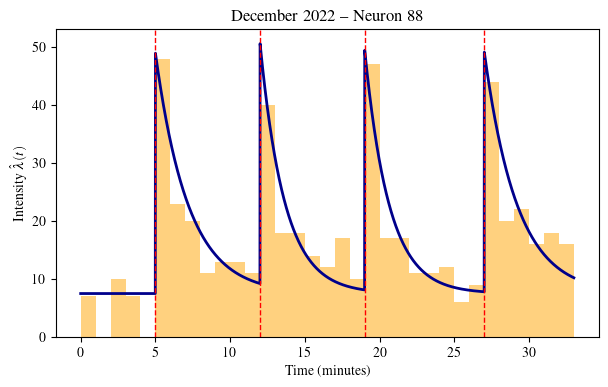

In [10]:
init_params1 = [np.log(10), np.log(10), np.log(7.5), np.log(0.01), np.log(1.0), np.log(0.1), np.log(0.05)] 
init_params2 = [np.log(5), np.log(10), np.log(0.5), np.log(0.1), np.log(1.0), np.log(0.1), np.log(0.01)]
init_params3 = [np.log(10), np.log(50), np.log(7.5), np.log(0.01), np.log(1.0), np.log(0.1), np.log(0.05)]

pvals = {}; mods = {}
for i in range(len(peak_times)):
    pp1 = hep.fit_process(init_params1, peak_times[i], stimuli, T, weights=None, observation_intervals=None, sum_values=False,
                            add_delay=False, fixed_jumps=False, fixed_decay=False, fixed_delay=False, inhibitory_decay=False, inhibitory_delay=False)
    pp2 = hep.fit_process(init_params2, peak_times[i], stimuli, T, weights=None, observation_intervals=None, sum_values=False,
                            add_delay=False, fixed_jumps=False, fixed_decay=False, fixed_delay=False, inhibitory_decay=False, inhibitory_delay=False)
    pp3 = hep.fit_process(init_params3, peak_times[i], stimuli, T, weights=None, observation_intervals=None, sum_values=False,
                            add_delay=False, fixed_jumps=False, fixed_decay=False, fixed_delay=False, inhibitory_decay=False, inhibitory_delay=False)
    ## Choose best fit among three initializations
    fits = [pp1, pp2, pp3]
    fits_ll = [fit.fun for fit in fits]
    best_fit_index = np.argmin(fits_ll)
    pp = fits[best_fit_index]
    mods[i] = pp
    curve = hep.calculate_intensity(params=pp.x, t=np.linspace(0, T, T*100), jumps=stimuli, 
                                    add_delay=False, fixed_jumps=False, fixed_decay=False, fixed_delay=False, inhibitory_decay=False, inhibitory_delay=False, log_params=True)
    pvals[i] = hep.calculate_compensator(params=pp.x, event_times=np.array(peak_times[i]), T=T, jumps=stimuli, add_delay=False, fixed_jumps=False, 
                          fixed_decay=False, fixed_delay=False, inhibitory_decay=False, inhibitory_delay=False, log_params=True)
    plt.figure(figsize=(7, 4))
    plt.plot(np.linspace(0, T, T*100), curve, color='darkblue', lw=2, zorder=2)
    plt.hist(peak_times[i], bins=np.arange(0, T+1, 1), density=False, alpha=0.5, color='orange', zorder=1)
    for stimulus in stimuli:
        plt.axvline(x=stimulus, color='r', linestyle='--', lw=1)
    plt.title(f'December 2022 -- Neuron {i+1}')

    plt.xlabel('Time (minutes)')
    plt.ylabel(r'Intensity $\hat{\lambda}(t)$')

    plt.savefig(f'../figures/Dec0922/Dec0922_neuron_{i+1}_fit.pdf', bbox_inches='tight')
    plt.show(block=False)

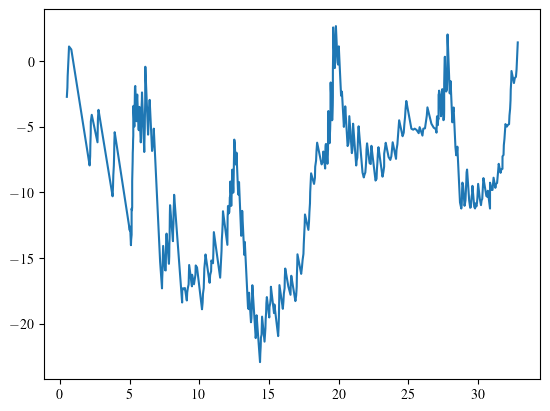

In [20]:
plt.plot(peak_times[87], np.arange(0, len(peak_times[87])) + 1 - pvals[87])
## plt.plot(peak_times[87], np.arange(0, len(peak_times[87])) + 1 - len(peak_times[87]) / T * (np.arange(0, len(peak_times[87])) + 1))

[]

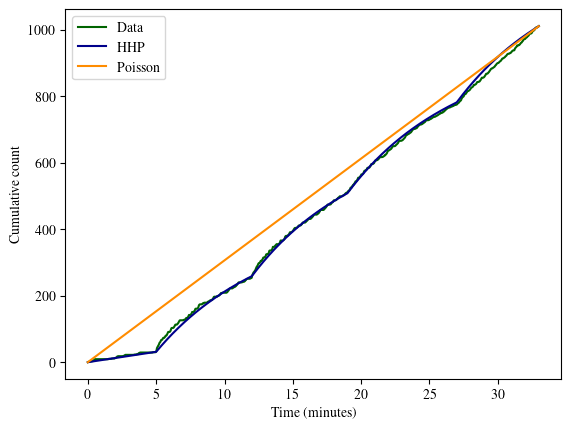

In [ ]:
plt.plot(np.linspace(0,T,1000), np.searchsorted(peak_times[35], np.linspace(0,T,1000)), c='DarkGreen', label='Data')
plt.plot(np.linspace(0,T,1000), hep.calculate_compensator(params=mods[35].x, event_times=np.linspace(0,T,1000), T=T, jumps=stimuli, add_delay=False, fixed_jumps=False, 
                          fixed_decay=False, fixed_delay=False, inhibitory_decay=False, inhibitory_delay=False, log_params=True), c='DarkBlue', label='HHP')
plt.plot(np.linspace(0,T,1000), len(peak_times[35]) / T * np.linspace(0,T,1000), c='DarkOrange', label='Poisson')
plt.xlabel('Time (minutes)')
plt.ylabel('Cumulative count')
plt.legend()
plt.plot()

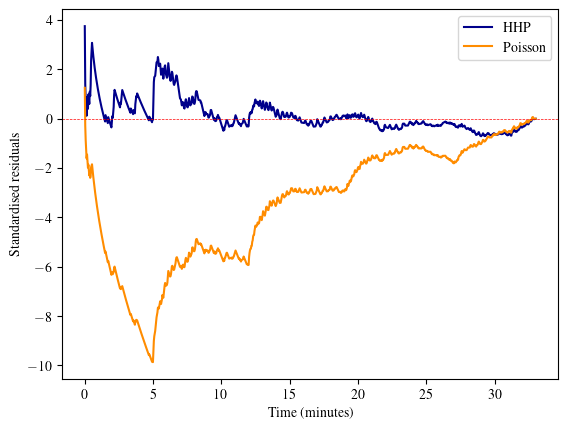

In [ ]:
## plt.plot(np.linspace(0,T,1000), np.searchsorted(peak_times[87], np.linspace(0,T,1000)), c='DarkGreen', label='Data')
Lam = hep.calculate_compensator(params=mods[35].x, event_times=np.linspace(0.01,T,1000), T=T, jumps=stimuli, add_delay=False, fixed_jumps=False, 
                          fixed_decay=False, fixed_delay=False, inhibitory_decay=False, inhibitory_delay=False, log_params=True)
plt.plot(np.linspace(0.01,T,1000), (np.searchsorted(peak_times[35], np.linspace(0.01,T,1000)) - Lam) / np.sqrt(Lam), c='DarkBlue', label='HHP')
plt.plot(np.linspace(0.01,T,1000), (np.searchsorted(peak_times[35], np.linspace(0.01,T,1000)) - len(peak_times[35]) / T * np.linspace(0.01,T,1000)) / np.sqrt(len(peak_times[35]) / T * np.linspace(0.01,T,1000)), c='DarkOrange', label='Poisson')
plt.axhline(y=0, color='r', linestyle='--', lw=0.5)
plt.xlabel('Time (minutes)')
plt.ylabel('Standardised residuals')
plt.legend()
plt.show()

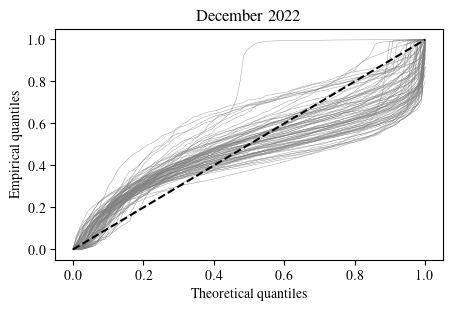

In [20]:
from scipy.stats import kstest
ks_scores = []
## Q-Q plot against uniform
plt.figure(figsize=(5, 3))
for i in range(len(peak_times)):
    plt.plot(np.linspace(0, 100, 100) / 100, np.percentile(np.exp(-np.diff(pvals[i])), np.linspace(0, 100, 100)), c='gray', lw=0.25)
    ## Calculate KS score
    ks_stat, p_value = kstest(np.exp(-np.diff(pvals[i])), 'uniform')
    ks_scores += [ks_stat]
plt.plot([0, 1], [0, 1], '--', color='black')
plt.xlabel('Theoretical quantiles')
plt.ylabel('Empirical quantiles')
plt.title('December 2022')
plt.savefig('../figures/Dec0922/Dec0922_qq_plots.pdf', bbox_inches='tight')
plt.show()

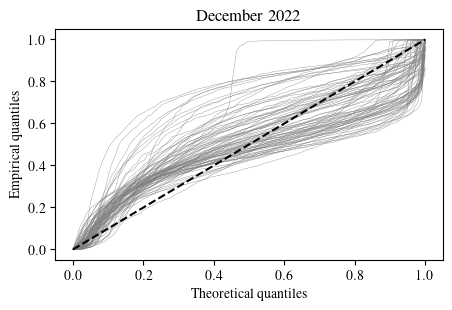

In [19]:
pp_pvals = {}
## Compare to Poisson process estimate
for i in range(len(peak_times)):
    rate = len(peak_times[i]) / T
    pp_pvals[i] = np.exp(-np.diff(rate * np.array(peak_times[i])))

## Q-Q plot against uniform
ks_scores_pp = []
plt.figure(figsize=(5, 3))
for i in range(len(peak_times)):
    plt.plot(np.linspace(0, 100, 100) / 100, np.percentile(pp_pvals[i], np.linspace(0, 100, 100)), c='gray', lw=0.25)
    ks_scores_pp += [kstest(pp_pvals[i], 'uniform')[0]]
plt.plot([0, 1], [0, 1], '--', color='black')
plt.xlabel('Theoretical quantiles')
plt.ylabel('Empirical quantiles')
plt.title('December 2022')
plt.savefig('../figures/Dec0922/Dec0922_qq_plots_poisson.pdf', bbox_inches='tight')
plt.show()

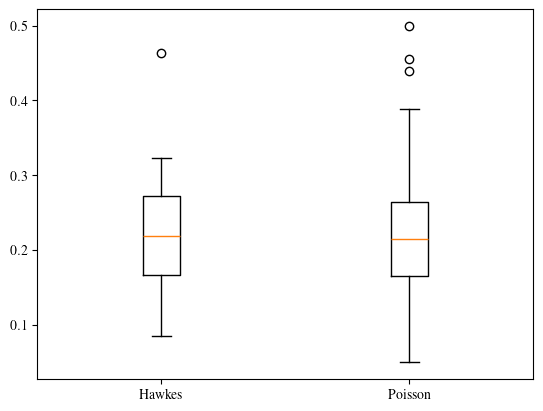

In [46]:
plt.boxplot([ks_scores, ks_scores_pp], tick_labels=['Hawkes', 'Poisson'])
plt.show()

In [47]:
np.argsort([ks_scores[i] - ks_scores_pp[i] for i in range(len(ks_scores))]) + 1

array([51, 50, 54, 57, 83, 75, 42,  3, 38, 19,  8, 84, 17, 43, 55, 76, 61,
       88, 78, 24, 82, 59, 81, 32, 79, 74, 85, 27, 22, 35, 26, 65, 71, 31,
       64, 28, 69, 73, 72, 25, 30, 66, 67, 16, 68, 21, 70, 86, 87, 60, 63,
       36, 29,  1, 14, 34, 10, 77,  5, 12, 18, 23, 13, 11, 15, 20, 80, 48,
        4, 33, 47, 56, 37,  6,  9,  2, 58, 53,  7, 49, 46, 41, 44, 62, 45,
       39, 40, 52])

In [ ]:
np.where(np.argsort([ks_scores[i] - ks_scores_pp[i] for i in range(len(ks_scores))]) + 1 == 36)

(array([51]),)

In [64]:
## Calculate autocorrelation
#from statsmodels.graphics.tsaplots import plot_acf
#for i in range(len(peak_times)):
#    plot_acf(np.diff(pvals[i]), lags=15)
#    plot_acf(len(peak_times[i]) / T * np.diff(peak_times[i]), lags=15)
#    plt.title(f'Neuron {i+1}')
#    plt.show()

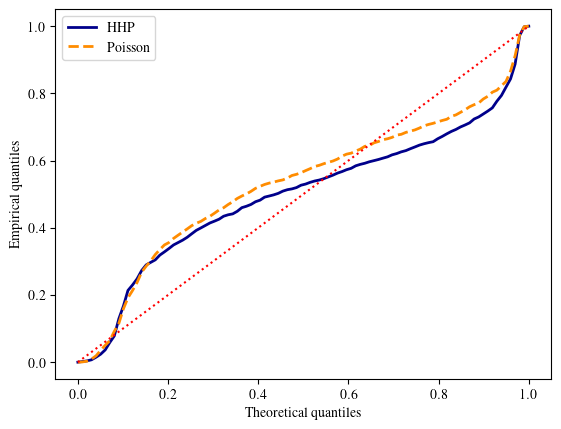

In [63]:
## Plot Q-Q plots for last neuron (87)
plt.plot(np.linspace(0, 100, 100) / 100, np.percentile(np.exp(-np.diff(pvals[35])), np.linspace(0, 100, 100)), c='DarkBlue', lw=2, label='HHP')
plt.plot(np.linspace(0, 100, 100) / 100, np.percentile(pp_pvals[35], np.linspace(0, 100, 100)), c='DarkOrange', lw=2, ls='--', label='Poisson')
plt.plot([0, 1], [0, 1], 'r', ls='dotted')
plt.xlabel('Theoretical quantiles')
plt.ylabel('Empirical quantiles')
plt.legend()
plt.show()